# Eksperimen Cross-Project Menggunakan Dataset IDoFT (Java) & Konsep Afeltra

Notebook ini menerapkan konsep dari paper Afeltra (2024) mengenai Cross-Project Flaky Test Prediction, namun dengan modifikasi:
1. Menggunakan **IDoFT Dataset** (International Dataset of Flaky Tests) khusus proyek Java (`pr-data.csv` dan `gr-data.csv`).
2. Menguji berbagai model (Random Forest, Extra Trees, Gradient Boosting, Logistic Regression) yang telah diuji di eksperimen sebelumnya.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

sns.set_theme(style="whitegrid")


In [11]:
# Load IDoFT Data (Java projects only)
pr_data = pd.read_csv('idoft-main/idoft-main/pr-data.csv')
gr_data = pd.read_csv('idoft-main/idoft-main/gr-data.csv')
idoft_java = pd.concat([pr_data, gr_data], ignore_index=True)

print(f"Total flaky tests di IDoFT (Java): {len(idoft_java)}")

# Extract project name from URL to match with FlakeFlagger data
idoft_java['project_clean'] = idoft_java['Project URL'].apply(
    lambda x: x.split('/')[-1].lower() if isinstance(x, str) else ""
)
# Gunakan test name versi full lowercase untuk cross-matching
idoft_java['TestName'] = idoft_java['Fully-Qualified Test Name (packageName.ClassName.methodName)'].apply(
    lambda x: str(x).lower()
)


Total flaky tests di IDoFT (Java): 9104


In [12]:
# Load FlakeFlagger features (sebagai sumber fitur)
# Path ke test_features.csv di root directory
df_features = pd.read_csv('../../../test_features.csv')
df_features['project_clean'] = df_features['project'].str.lower()
df_features['TestName'] = df_features['test_name'].apply(
    lambda x: str(x).lower()
)

print(f"Total data di test_features: {len(df_features)}")


Total data di test_features: 22236


In [13]:
# Matching IDoFT label ke FlakeFlagger features
# Kita gunakan FlakeFlagger features, tapi label 'flaky'-nya dioverride berdasarkan IDoFT
idoft_flaky_set = set(zip(idoft_java['project_clean'], idoft_java['TestName']))

def is_idoft_flaky(row):
    return 1 if (row['project_clean'], row['TestName']) in idoft_flaky_set else 0

df_features['idoft_flaky'] = df_features.apply(is_idoft_flaky, axis=1)

# Ambil subset data: Proyek yang setidaknya punya 1 flaky test di IDoFT
idoft_projects = idoft_java['project_clean'].unique()
df = df_features[df_features['project_clean'].isin(idoft_projects)].copy()

print(f"Data setelah difilter dengan proyek IDoFT: {len(df)}")
print(f"Jumlah Flaky di dataset baru: {df['idoft_flaky'].sum()}")

# Hapus kolom metadata untuk mendapatkan features saja
metadata_cols = {'Unnamed: 0', 'test_name', 'project', 'project_clean', 'TestName', 'flaky', 'idoft_flaky', 'testClassName', 'testMethodName'}
feature_cols = [c for c in df.columns if c not in metadata_cols]


Data setelah difilter dengan proyek IDoFT: 12626
Jumlah Flaky di dataset baru: 264


In [14]:
# TrAdaBoost Implementation
class TrAdaBoostClassifier:
    def __init__(self, base_estimator=DecisionTreeClassifier(max_depth=3), n_estimators=10):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.estimators_ = []
        self.beta_all = []
        
    def fit(self, X_source, y_source, X_target, y_target):
        X = np.vstack((X_source, X_target))
        y = np.hstack((y_source, y_target))
        
        n_source = X_source.shape[0]
        n_target = X_target.shape[0]
        n = n_source + n_target
        
        weights = np.ones(n) / n
        beta = 1.0 / (1.0 + np.sqrt(2 * np.log(n_source / self.n_estimators)))
        
        for i in range(self.n_estimators):
            weights = weights / np.sum(weights)
            estimator = clone(self.base_estimator)
            estimator.fit(X, y, sample_weight=weights)
            self.estimators_.append(estimator)
            
            pred = estimator.predict(X)
            error_target = np.sum(weights[n_source:] * (pred[n_source:] != y[n_source:]))
            if error_target > 0.5: error_target = 0.5
            if error_target == 0: beta_target = 1.0
            else: beta_target = error_target / (1.0 - error_target)
                
            self.beta_all.append(beta_target)
            
            for j in range(n_source):
                if pred[j] != y[j]: weights[j] *= beta
            for j in range(n_target):
                if pred[n_source + j] != y[n_source + j]: weights[n_source + j] *= (1.0 / beta_target)
                    
        return self
        
    def predict(self, X):
        preds = np.zeros((X.shape[0], len(self.estimators_)))
        for i, estimator in enumerate(self.estimators_):
            preds[:, i] = estimator.predict(X)
            
        final_preds = []
        for i in range(X.shape[0]):
            weight_0, weight_1 = 0, 0
            for j in range(self.n_estimators):
                if preds[i, j] == 0: weight_0 += np.log(1.0 / (self.beta_all[j] + 1e-10))
                else: weight_1 += np.log(1.0 / (self.beta_all[j] + 1e-10))
            final_preds.append(1 if weight_1 > weight_0 else 0)
        return np.array(final_preds)


In [15]:
# Deteksi GPU untuk XGBoost (RTX 4050 CUDA 12 dsb.)
from xgboost import XGBClassifier
import xgboost as xgb

try:
    # Uji sederhana apakah XGBoost bisa menggunakan CUDA
    test_xgb = XGBClassifier(tree_method='hist', device='cuda', n_estimators=1)
    test_xgb.fit(np.array([[0]]), np.array([0]))
    xgb_device = 'cuda'
    print("GPU Terdeteksi! XGBoost akan menggunakan CUDA.")
except Exception as e:
    xgb_device = 'cpu'
    print("GPU tidak terdeteksi atau terjadi error, XGBoost akan menggunakan CPU.")

# Definisi Model Algoritma yang ingin diuji
models_to_test = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=27.0, tree_method='hist', device=xgb_device) # scale_pos_weight = (mayoritas/minoritas) rata-rata 3.6% -> ~27
}


GPU Terdeteksi! XGBoost akan menggunakan CUDA.


In [16]:
# LOOCV dengan Afeltra Concept & Berbagai Model
projects = [p for p in df['project_clean'].unique() if df[df['project_clean'] == p]['idoft_flaky'].sum() > 0]
print(f"Total projects untuk LOOCV (yang punya data flaky): {len(projects)}")

results = []

def get_metrics(y_true, y_pred):
    if len(np.unique(y_true)) == 1:
        return 0.0, 0.0, 0.0, 0.0, 0.0
    return (
        f1_score(y_true, y_pred, zero_division=0),
        matthews_corrcoef(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        roc_auc_score(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0.5
    )

for p_test_name in projects:
    print(f"\n--- Target Project: {p_test_name} ---")
    
    df_train = df[df['project_clean'] != p_test_name]
    df_test = df[df['project_clean'] == p_test_name]
    
    X_train_raw = df_train[feature_cols].values
    y_train = df_train['idoft_flaky'].values
    X_test_raw = df_test[feature_cols].values
    y_test = df_test['idoft_flaky'].values
    
    if len(np.unique(y_test)) < 2:
        print(f"Project {p_test_name} hanya memiliki 1 kelas, skip evaluasi.")
        continue
        
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train_raw)
    X_test_imp = imputer.transform(X_test_raw)
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_test_sc = scaler.transform(X_test_imp)
    
    smote = SMOTE(random_state=42)
    try:
        X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)
    except:
        X_train_res, y_train_res = X_train_sc, y_train
        
    for model_name, base_model in models_to_test.items():
        # 1. Baseline
        model = clone(base_model)
        model.fit(X_train_res, y_train_res)
        y_pred_base = model.predict(X_test_sc)
        
        # 2. Burak Filter
        K = min(500, len(X_train_sc))
        knn = NearestNeighbors(n_neighbors=K)
        knn.fit(X_train_sc)
        _, indices = knn.kneighbors(X_test_sc)
        burak_indices = np.unique(indices.flatten())
        
        X_tr_burak = X_train_sc[burak_indices]
        y_tr_burak = y_train[burak_indices]
        
        try: X_tr_burak_res, y_tr_burak_res = smote.fit_resample(X_tr_burak, y_tr_burak)
        except: X_tr_burak_res, y_tr_burak_res = X_tr_burak, y_tr_burak
            
        model_burak = clone(base_model)
        if len(np.unique(y_tr_burak_res)) > 1:
            model_burak.fit(X_tr_burak_res, y_tr_burak_res)
            y_pred_burak = model_burak.predict(X_test_sc)
        else:
            y_pred_burak = np.zeros_like(y_test)
            
        # 3. TrAdaBoost (Proxy)
        split_idx = int(len(X_test_sc) * 0.2)
        if split_idx > 0 and len(np.unique(y_test[:split_idx])) > 1:
            X_target_train, y_target_train = X_test_sc[:split_idx], y_test[:split_idx]
            X_target_test, y_target_test = X_test_sc[split_idx:], y_test[split_idx:]
            
            base_estimator = DecisionTreeClassifier(max_depth=3) # TrAdaBoost typical
            trada = TrAdaBoostClassifier(base_estimator=base_estimator, n_estimators=20)
            sub_idx = np.random.choice(len(X_train_sc), min(2000, len(X_train_sc)), replace=False)
            
            trada.fit(X_train_sc[sub_idx], y_train[sub_idx], X_target_train, y_target_train)
            y_pred_trada = trada.predict(X_target_test)
            y_test_eval_trada = y_target_test
        else:
            y_pred_trada = y_pred_base
            y_test_eval_trada = y_test
            
        # 4. Within-Project Upper Bound
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        y_pred_within = np.zeros_like(y_test)
        if len(np.unique(y_test)) > 1 and len(y_test) >= 5:
            for train_idx, test_idx in skf.split(X_test_raw, y_test):
                X_tr_w, X_te_w = X_test_raw[train_idx], X_test_raw[test_idx]
                y_tr_w, y_te_w = y_test[train_idx], y_test[test_idx]
                
                imp_w = SimpleImputer(strategy='median')
                X_tr_w_sc = scaler.fit_transform(imp_w.fit_transform(X_tr_w))
                X_te_w_sc = scaler.transform(imp_w.transform(X_te_w))
                
                model_w = clone(base_model)
                if len(np.unique(y_tr_w)) > 1:
                    model_w.fit(X_tr_w_sc, y_tr_w)
                    y_pred_within[test_idx] = model_w.predict(X_te_w_sc)
                else:
                    y_pred_within[test_idx] = y_tr_w[0]
                
        # Store metrics
        metrics = {
            f'{model_name}_Baseline': get_metrics(y_test, y_pred_base),
            f'{model_name}_Burak': get_metrics(y_test, y_pred_burak),
            f'{model_name}_TrAdaBoost': get_metrics(y_test_eval_trada, y_pred_trada),
            f'{model_name}_Within': get_metrics(y_test, y_pred_within)
        }
        
        for k, v in metrics.items():
            alg, interv = k.split('_')
            results.append({
                'Project': p_test_name,
                'Algorithm': alg,
                'Intervention': interv,
                'F1-Score': v[0],
                'MCC': v[1],
                'Precision': v[2],
                'Recall': v[3],
                'AUC-ROC': v[4]
            })

df_results = pd.DataFrame(results)
print("Eksperimen Selesai!")


Total projects untuk LOOCV (yang punya data flaky): 13

--- Target Project: logback ---

--- Target Project: http-request ---

--- Target Project: okhttp ---

--- Target Project: achilles ---

--- Target Project: undertow ---

--- Target Project: activiti ---

--- Target Project: hbase ---

--- Target Project: httpcore ---

--- Target Project: java-websocket ---

--- Target Project: wildfly ---

--- Target Project: spring-boot ---

--- Target Project: wro4j ---

--- Target Project: alluxio ---
Eksperimen Selesai!


F1-Score    MCC  AUC-ROC
Algorithm          Intervention                          
ExtraTrees         Baseline         0.000 -0.003    0.499
                   Burak            0.000 -0.002    0.499
                   TrAdaBoost       0.000 -0.005    0.498
                   Within           0.379  0.365    0.670
GradientBoosting   Baseline         0.035  0.018    0.501
                   Burak            0.039  0.022    0.496
                   TrAdaBoost       0.038  0.026    0.513
                   Within           0.350  0.334    0.657
LogisticRegression Baseline         0.088  0.025    0.547
                   Burak            0.058  0.026    0.600
                   TrAdaBoost       0.063  0.042    0.564
                   Within           0.306  0.310    0.745
RandomForest       Baseline         0.000 -0.001    0.500
                   Burak            0.000 -0.001    0.500
                   TrAdaBoost       0.026  0.026    0.508
                   Within           0.402  0.387    0.685
XGBoost            Baseline         0.009 -0.003    0.494
                   Burak            0.022  0.012    0.496
                   TrAdaBoost       0.003 -0.010    0.491
                   Within           0.324  0.304    0.653

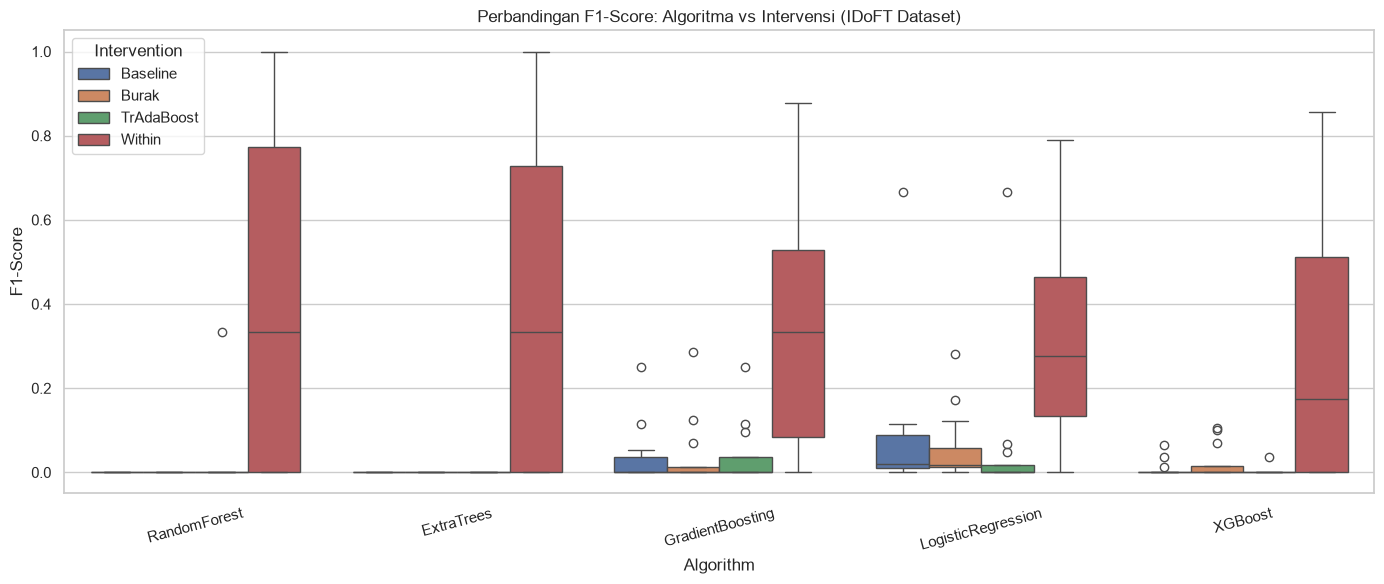

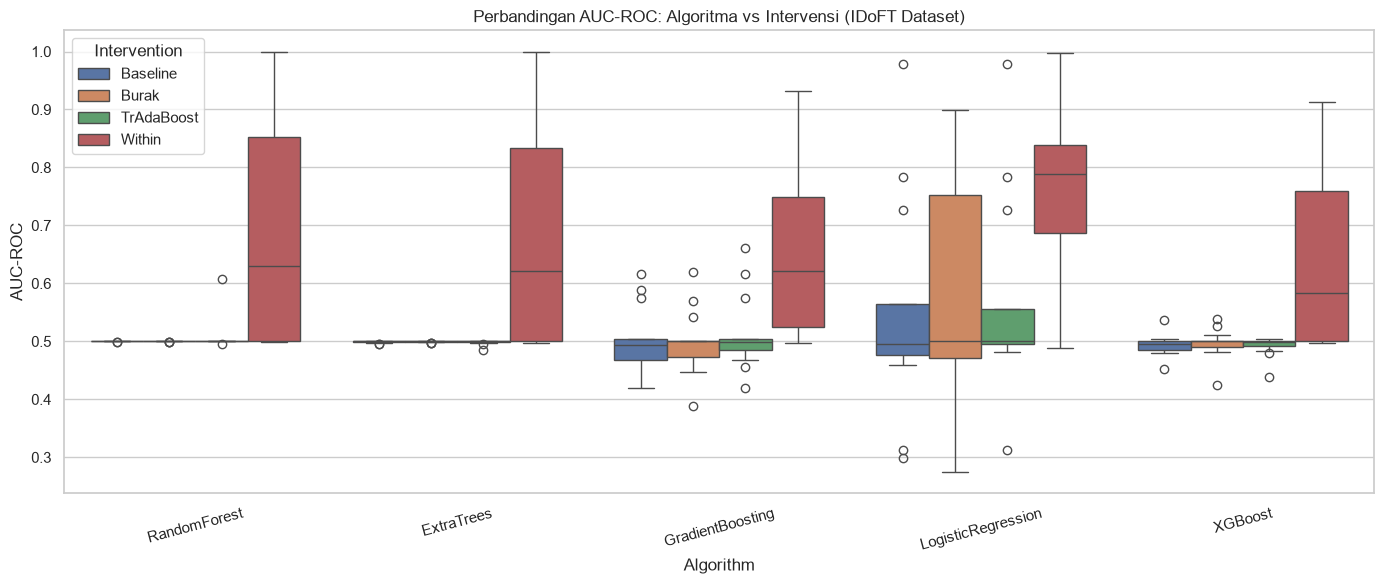

In [17]:
# Summary Hasil
summary = df_results.groupby(['Algorithm', 'Intervention']).agg({
    'F1-Score': 'mean', 'MCC': 'mean', 'AUC-ROC': 'mean'
}).round(3)
display(summary)

# Plotting F1-Score
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_results, x='Algorithm', y='F1-Score', hue='Intervention')
plt.title('Perbandingan F1-Score: Algoritma vs Intervensi (IDoFT Dataset)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Plotting AUC-ROC
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_results, x='Algorithm', y='AUC-ROC', hue='Intervention')
plt.title('Perbandingan AUC-ROC: Algoritma vs Intervensi (IDoFT Dataset)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
